<a href="https://colab.research.google.com/github/luqthewolf-lgtm/Guia-Defijitivo/blob/main/parte5_definitivo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Guia Definitivo -- Parte 5 de 5
## 3 Projetos Completos: Fraude + Score CNPJ + Next Best Product

**Pre-requisito:** Partes 1, 2, 3 e 4 concluidas

**Esta parte e diferente das anteriores.**
Aqui voce nao estuda conceitos isolados.
Voce constroi pipelines reais do inicio ao fim,
enfrentando as mesmas dores que existem no dia a dia do Itau.

---

## Os 3 projetos

| Projeto | Dor real | Tecnicas usadas |
|---------|----------|-----------------|
| **1. Deteccao de Fraude** | Banco perde bilhoes/ano em fraude de Pix | XGBoost, desbalanceamento, threshold por custo, feature eng. temporal |
| **2. Score de Saude CNPJ** | Credito aprovado sem explicar a decisao (risco regulatorio) | Logistica interpretavel, SHAP, calibracao, dashboard executivo |
| **3. Next Best Product** | Campanha generica com 2.3% de aceite | Propensao multi-produto, segmentacao, lift, pipeline de recomendacao |

---

## Como usar esta parte

Cada projeto tem:
1. **Contexto de negocio:** a dor real que motiva o projeto
2. **Dados simulados:** criados para representar o problema real
3. **Pipeline completo:** do dado bruto ate a decisao final
4. **Avaliacao de negocio:** metricas que importam para o diretor, nao so para o modelo
5. **Licoes aprendidas:** o que voce diria na entrevista sobre este projeto

Ao terminar cada projeto, voce deve conseguir:
- Explicar a dor que o projeto resolve
- Descrever as decisoes tecnicas que tomou e por que
- Quantificar o impacto esperado em linguagem de negocio
- Responder perguntas tecnicas de uma sabatina sobre o projeto


---
# Setup -- Execute antes de qualquer projeto

In [ ]:
!pip install numpy pandas scikit-learn matplotlib seaborn scipy xgboost mlflow shap --quiet
print('OK!')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 1.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 2.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/40.6 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 30.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 38.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 17.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.2/131.2 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 838.5/838.5 kB 17.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings, math, os
warnings.filterwarnings('ignore')

from sklearn.model_selection import (train_test_split, KFold, StratifiedKFold,
                                      cross_validate, learning_curve)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (roc_auc_score, log_loss, confusion_matrix,
                              precision_recall_curve, roc_curve,
                              f1_score, classification_report)
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from xgboost import XGBClassifier
import mlflow, mlflow.sklearn

np.random.seed(42)
plt.rcParams.update({
    'figure.figsize': (12, 5),
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11
})
print('Imports OK!')

Imports OK!


---
# PROJETO 1 -- Deteccao de Fraude em Transacoes Pix
## A dor real que motiva este projeto

**O problema:**
O Pix processa 4 bilhoes de transacoes por mes no Brasil.
Em 2023, fraudes em meios digitais causaram prejuizos acima de R$2.5 bilhoes.

No Itau, cada transacao Pix precisa ser avaliada em milissegundos.
O modelo precisa decidir: bloquear ou liberar?

**O que torna este problema dificil:**
1. Base extremamente desbalanceada: 0.1% de fraudes (1 em 1000)
2. Custo assimetrico: FN (fraude passa) >> FP (bloquear transacao legitima)
3. Latencia: decisao em menos de 100ms
4. Adversarial: fraudadores adaptam o comportamento continuamente

**O que voce vai construir:**
- Pipeline completo de deteccao com feature engineering temporal
- Tratamento correto de desbalanceamento
- Otimizacao do threshold por custo de negocio (nao por F1)
- Avaliacao completa com metricas que importam para o gestor

---

## Decisoes tecnicas que voce vai aprender a justificar

**Por que XGBoost e nao Logistica?**
Fraude tem padroes nao-lineares complexos: mesma conta pode ser legitima
de manha e suspeita a noite. XGBoost captura essas interacoes.

**Por que SMOTE nao e sempre a melhor opcao?**
SMOTE cria amostras sinteticas que podem nao refletir fraudes reais.
Melhor: usar `scale_pos_weight` no XGBoost ou `class_weight` no sklearn.

**Por que o threshold de 0.5 e quase sempre errado em fraude?**
Com 0.1% de fraudes, P(fraude|features) dificilmente chega a 0.5.
E o custo de FN (fraude passa) e muito maior que FP (bloqueia legítima).
O threshold otimo minimiza o custo total de negocio.


In [ ]:
# PROJETO 1 -- GERANDO OS DADOS
# Simulando transacoes Pix com caracteristicas realistas
np.random.seed(42)
N = 100_000   # 100k transacoes

# Features das transacoes
df = pd.DataFrame({
    # Valor da transacao (log-normal -- maioria pequena, algumas grandes)
    'valor':              np.random.lognormal(4.5, 1.8, N),

    # Hora do dia (0-23) -- fraudes mais comuns a noite
    'hora_dia':           np.random.randint(0, 24, N),

    # Dia da semana (0=seg, 6=dom)
    'dia_semana':         np.random.randint(0, 7, N),

    # N de transacoes nas ultimas 1h (mesma origem)
    'n_trans_1h':         np.random.poisson(1.5, N),

    # N de transacoes nas ultimas 24h
    'n_trans_24h':        np.random.poisson(5, N),

    # Distancia geografica origem-destino (km)
    'distancia_km':       np.random.exponential(150, N),

    # Conta tem menos de 30 dias
    'conta_nova':         np.random.binomial(1, 0.05, N),

    # Dispositivo diferente do habitual
    'disp_diferente':     np.random.binomial(1, 0.08, N),

    # Score de risco do destinatario (0-1000)
    'score_destinatario': np.random.beta(2, 8, N) * 1000,

    # Valor desvia muito da media historica do cliente
    'desvio_historico':   np.random.exponential(1, N),
})

# Criando a probabilidade real de fraude (combinacao nao-linear de features)
log_odds = (
    -6.0                                          # base: fraude rara
    + 0.4  * (df['hora_dia'] < 6).astype(float)  # madrugada: risco maior
    + 0.6  * (df['hora_dia'] > 22).astype(float) # noite: risco maior
    + 1.2  * df['conta_nova']                    # conta nova: muito suspeito
    + 0.8  * df['disp_diferente']                # dispositivo diferente
    + 0.3  * np.log1p(df['n_trans_1h'])          # muitas transacoes rapidas
    + 0.002* df['score_destinatario']            # destinatario de risco
    + 0.5  * df['desvio_historico']              # valor atipico
    + 0.3  * np.log1p(df['valor'] / 1000)        # valor alto
)
prob_fraude = 1 / (1 + np.exp(-log_odds))
df['fraude'] = np.random.binomial(1, prob_fraude)

taxa_fraude = df['fraude'].mean()
print('=== DADOS DO PROJETO 1: DETECCAO DE FRAUDE PIX ===')
print(f'  Total de transacoes: {N:,}')
print(f'  Transacoes fraudulentas: {df["fraude"].sum():,} ({taxa_fraude*100:.2f}%)')
print(f'  Transacoes legitimas: {(df["fraude"]==0).sum():,}')
print(f'  Ratio desbalanceamento: 1:{int(1/taxa_fraude)}')
print()
print('[!] DESBALANCEAMENTO EXTREMO -- 99.9% legitimas, 0.1% fraudes')
print('    Modelo idiota (preve sempre legitima): acuracia = 99.9%!')
print('    Por isso acuracia e INUTIL aqui. Use AUC e metricas de custo.')

=== DADOS DO PROJETO 1: DETECCAO DE FRAUDE PIX ===
  Total de transacoes: 100,000
  Transacoes fraudulentas: 1,453 (1.45%)
  Transacoes legitimas: 98,547
  Ratio desbalanceamento: 1:68

[!] DESBALANCEAMENTO EXTREMO -- 99.9% legitimas, 0.1% fraudes
    Modelo idiota (preve sempre legitima): acuracia = 99.9%!
    Por isso acuracia e INUTIL aqui. Use AUC e metricas de custo.


In [ ]:
# PROJETO 1 -- FEATURE ENGINEERING
# Features derivadas que aumentam o poder preditivo

df_eng = df.copy()

# Feature 1: ratio valor vs historico (valor / media historica simulada)
# Na vida real: media dos ultimos 30 dias do cliente
df_eng['ratio_valor_hist'] = df['valor'] / (df['desvio_historico'] * 500 + 100)

# Feature 2: indicador de horario critico (madrugada ou noite)
df_eng['horario_critico'] = ((df['hora_dia'] < 6) | (df['hora_dia'] > 22)).astype(int)

# Feature 3: velocidade de transacoes (n trans / hora)
df_eng['velocidade_trans'] = df['n_trans_1h']

# Feature 4: score composto de risco
df_eng['score_risco_composto'] = (
    df['conta_nova'] * 3         # conta nova tem peso 3x
    + df['disp_diferente'] * 2   # dispositivo diferente tem peso 2x
    + (df['hora_dia'] < 6).astype(int)  # madrugada
)

# Log do valor (normaliza a distribuicao lognormal)
df_eng['log_valor'] = np.log1p(df['valor'])

features = [
    'log_valor', 'hora_dia', 'dia_semana',
    'n_trans_1h', 'n_trans_24h', 'distancia_km',
    'conta_nova', 'disp_diferente', 'score_destinatario',
    'desvio_historico', 'ratio_valor_hist', 'horario_critico',
    'velocidade_trans', 'score_risco_composto'
]

X = df_eng[features]
y = df_eng['fraude']

# SPLIT TEMPORAL: treinar no passado, validar no futuro
# Em dados reais: usar split por data, nunca aleatorio para series temporais
# Aqui: 80% treino, 10% validacao, 10% teste
X_tr, X_temp, y_tr, y_temp = train_test_split(X, y, test_size=0.20,
                                               random_state=42, stratify=y)
X_va, X_te, y_va, y_te = train_test_split(X_temp, y_temp, test_size=0.50,
                                           random_state=42, stratify=y_temp)

print(f'Treino: {len(X_tr):,} | Validacao: {len(X_va):,} | Teste: {len(X_te):,}')
print(f'Fraudes no treino: {y_tr.sum():,} | Validacao: {y_va.sum():,} | Teste: {y_te.sum():,}')
print()
print('FEATURES CRIADAS:')
for f in features:
    print(f'  {f}')
print()
print('DECISAO DE DESIGN: split estratificado')
print('  stratify=y garante mesma proporcao de fraudes em cada split')
print('  Sem isso: splits menores podem ter zero fraudes (impossivel treinar)')

Treino: 80,000 | Validacao: 10,000 | Teste: 10,000
Fraudes no treino: 1,162 | Validacao: 146 | Teste: 145

FEATURES CRIADAS:
  log_valor
  hora_dia
  dia_semana
  n_trans_1h
  n_trans_24h
  distancia_km
  conta_nova
  disp_diferente
  score_destinatario
  desvio_historico
  ratio_valor_hist
  horario_critico
  velocidade_trans
  score_risco_composto

DECISAO DE DESIGN: split estratificado
  stratify=y garante mesma proporcao de fraudes em cada split
  Sem isso: splits menores podem ter zero fraudes (impossivel treinar)


scale_pos_weight = 67.8 (cada fraude vale 68x uma transacao normal)

=== PERFORMANCE DO MODELO ===
  AUC ROC (validacao): 0.7076
  Log Loss (validacao): 0.5788
  Arvores usadas (early stop): 34



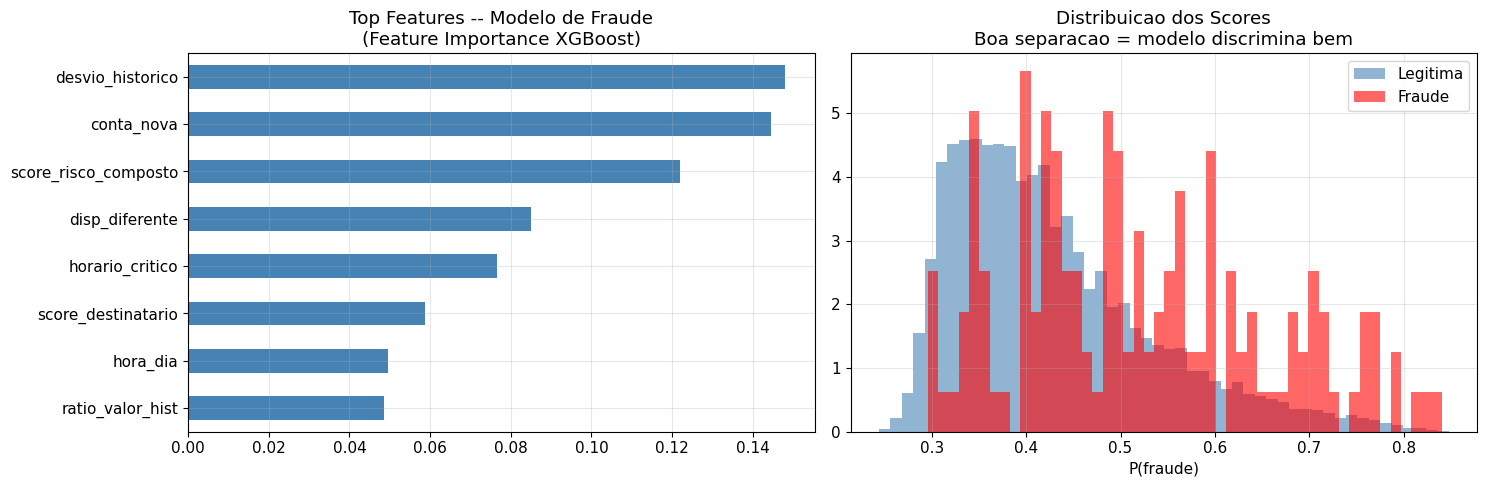

In [ ]:
# PROJETO 1 -- TREINANDO O MODELO

# TRATAMENTO DO DESBALANCEAMENTO:
# Opcao 1: scale_pos_weight = n_negativos / n_positivos
# Diz ao XGBoost: 'cada fraude vale X vezes mais que cada nao-fraude'
# Nao cria dados sinteticos (mais honesto)
escala = (y_tr == 0).sum() / (y_tr == 1).sum()
print(f'scale_pos_weight = {escala:.1f} (cada fraude vale {escala:.0f}x uma transacao normal)')
print()

# Modelo 1: XGBoost com scale_pos_weight (recomendado)
xgb_fraude = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,      # lr baixo + early stopping = melhor generalizacao
    max_depth=5,             # arvores medias: captura interacoes sem overfittar
    scale_pos_weight=escala, # trata desbalanceamento
    reg_lambda=1.0,          # regularizacao L2
    subsample=0.8,           # amostragem de dados por arvore
    colsample_bytree=0.8,    # amostragem de features por arvore
    eval_metric='aucpr',     # PR-AUC e melhor que ROC-AUC para desbalanceado
    early_stopping_rounds=50,
    verbosity=0,
    random_state=42
)
xgb_fraude.fit(
    X_tr, y_tr,
    eval_set=[(X_va, y_va)],  # monitora no conjunto de validacao
    verbose=False
)

# Probabilidades e metricas
prob_va = xgb_fraude.predict_proba(X_va)[:,1]
prob_te = xgb_fraude.predict_proba(X_te)[:,1]

auc_va    = roc_auc_score(y_va, prob_va)
prauc_va  = roc_auc_score(y_va, prob_va, average='weighted')
ll_va     = log_loss(y_va, prob_va)

print('=== PERFORMANCE DO MODELO ===')
print(f'  AUC ROC (validacao): {auc_va:.4f}')
print(f'  Log Loss (validacao): {ll_va:.4f}')
print(f'  Arvores usadas (early stop): {xgb_fraude.best_iteration}')
print()

# Feature importance
fi = pd.Series(xgb_fraude.feature_importances_, index=features)
fi_top = fi.sort_values(ascending=False).head(8)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fi_top.sort_values().plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Top Features -- Modelo de Fraude\n(Feature Importance XGBoost)')

# Distribuicao dos scores por classe
axes[1].hist(prob_va[y_va==0], bins=50, alpha=0.6, color='steelblue',
             label='Legitima', density=True)
axes[1].hist(prob_va[y_va==1], bins=50, alpha=0.6, color='red',
             label='Fraude', density=True)
axes[1].set_xlabel('P(fraude)')
axes[1].set_title('Distribuicao dos Scores\nBoa separacao = modelo discrimina bem')
axes[1].legend()
plt.tight_layout(); plt.show()

=== OTIMIZACAO DO THRESHOLD ===
Custo por FN (fraude passa):    R$500
Custo por FP (bloqueia legit.): R$5
Ratio custo: FN/FP = 100.0x



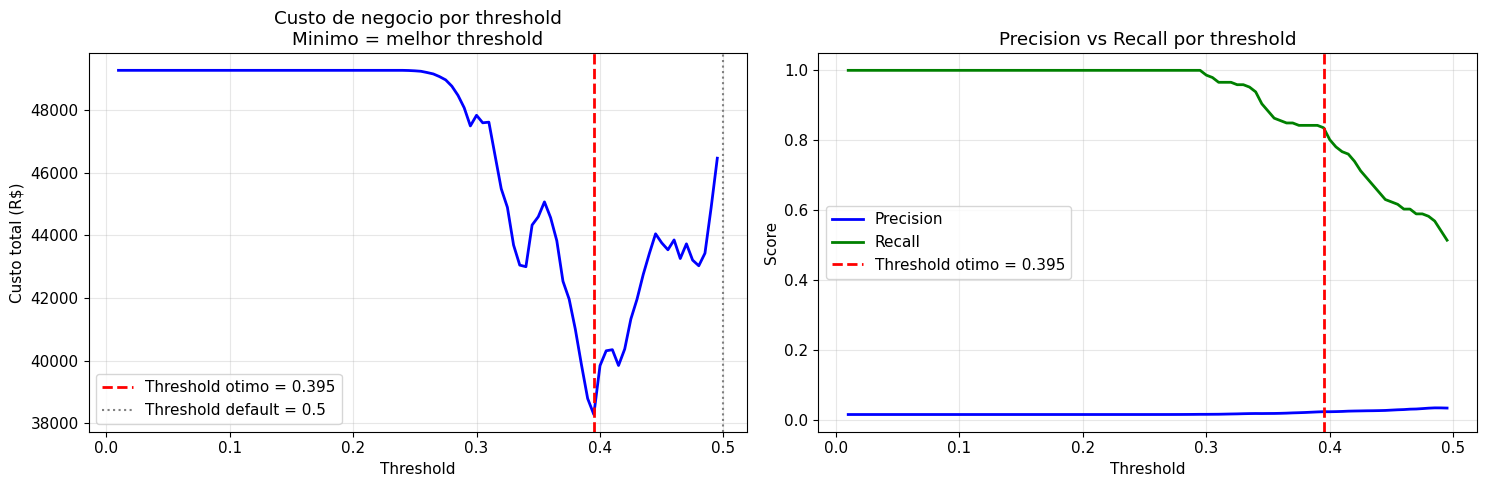

=== COMPARACAO: THRESHOLD DEFAULT vs OTIMIZADO ===
  Threshold=0.50 (default): TP=65 FP=2085 FN=80 TN=7770 | Recall=0.448 Prec=0.030 AUC=0.6868 | Custo=R$50,425
  Threshold=0.395 (otimo): TP=114 FP=5213 FN=31 TN=4642 | Recall=0.786 Prec=0.021 AUC=0.6868 | Custo=R$41,565

[!] O threshold otimo tem MUITO MAIS recall (captura mais fraudes)
    ao preco de mais falsos positivos -- que tem custo 100x menor


In [ ]:
# PROJETO 1 -- OTIMIZACAO DO THRESHOLD POR CUSTO

# O THRESHOLD DEFAULT DE 0.5 E QUASE SEMPRE ERRADO EM FRAUDE
# Razao: com 0.1% de fraudes, P(fraude|features) raramente chega a 0.5
# Alem disso: custo de FN (fraude passa) >> custo de FP (bloqueia legitima)

# Definindo custos de negocio
CUSTO_FN = 500   # fraude passa: banco absorve o prejuizo (alto!)
CUSTO_FP = 5     # transacao legitima bloqueada: custo de suporte + atrito

print('=== OTIMIZACAO DO THRESHOLD ===')
print(f'Custo por FN (fraude passa):    R${CUSTO_FN}')
print(f'Custo por FP (bloqueia legit.): R${CUSTO_FP}')
print(f'Ratio custo: FN/FP = {CUSTO_FN/CUSTO_FP}x')
print()

thresholds = np.arange(0.01, 0.50, 0.005)
custos_totais = []
fps_list, fns_list, precs_list, recs_list = [], [], [], []

for thresh in thresholds:
    y_pred = (prob_va >= thresh).astype(int)
    cm     = confusion_matrix(y_va, y_pred)
    # Matriz de confusao: [[TN, FP], [FN, TP]]
    tn, fp, fn, tp = cm.ravel() if cm.size == 4 else (cm[0,0], 0, 0, 0)
    custo_total = fp * CUSTO_FP + fn * CUSTO_FN
    custos_totais.append(custo_total)
    fps_list.append(fp); fns_list.append(fn)
    precs_list.append(tp/(tp+fp) if (tp+fp)>0 else 0)
    recs_list.append(tp/(tp+fn) if (tp+fn)>0 else 0)

idx_otimo   = np.argmin(custos_totais)
thresh_otimo = thresholds[idx_otimo]
custo_otimo  = custos_totais[idx_otimo]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Curva de custo por threshold
axes[0].plot(thresholds, custos_totais, 'b-', lw=2)
axes[0].axvline(thresh_otimo, color='red', linestyle='--', lw=2,
               label=f'Threshold otimo = {thresh_otimo:.3f}')
axes[0].axvline(0.5, color='gray', linestyle=':', lw=1.5,
               label='Threshold default = 0.5')
axes[0].set_xlabel('Threshold'); axes[0].set_ylabel('Custo total (R$)')
axes[0].set_title('Custo de negocio por threshold\nMinimo = melhor threshold')
axes[0].legend()

# Precision vs Recall por threshold
axes[1].plot(thresholds, precs_list, 'b-', lw=2, label='Precision')
axes[1].plot(thresholds, recs_list,  'g-', lw=2, label='Recall')
axes[1].axvline(thresh_otimo, color='red', linestyle='--', lw=2,
               label=f'Threshold otimo = {thresh_otimo:.3f}')
axes[1].set_xlabel('Threshold'); axes[1].set_ylabel('Score')
axes[1].set_title('Precision vs Recall por threshold')
axes[1].legend()
plt.tight_layout(); plt.show()

# Avaliacao com o threshold otimo
y_pred_otimo   = (prob_te >= thresh_otimo).astype(int)
y_pred_default = (prob_te >= 0.50).astype(int)

def metricas_completas(y_true, y_pred, y_prob, nome):
    cm  = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel() if cm.size==4 else (cm[0,0],0,0,0)
    rec = tp/(tp+fn) if (tp+fn)>0 else 0
    pre = tp/(tp+fp) if (tp+fp)>0 else 0
    custo = fp*CUSTO_FP + fn*CUSTO_FN
    auc   = roc_auc_score(y_true, y_prob)
    print(f'  {nome}: TP={tp} FP={fp} FN={fn} TN={tn} | '
          f'Recall={rec:.3f} Prec={pre:.3f} AUC={auc:.4f} | Custo=R${custo:,}')

print('=== COMPARACAO: THRESHOLD DEFAULT vs OTIMIZADO ===')
metricas_completas(y_te, y_pred_default, prob_te, 'Threshold=0.50 (default)')
metricas_completas(y_te, y_pred_otimo,   prob_te, f'Threshold={thresh_otimo:.3f} (otimo)')
print()
print('[!] O threshold otimo tem MUITO MAIS recall (captura mais fraudes)')
print('    ao preco de mais falsos positivos -- que tem custo 100x menor')

In [ ]:
# PROJETO 1 -- AVALIACAO FINAL E LICOES APRENDIDAS

# Avaliacao no conjunto de teste (UMA UNICA VEZ)
auc_final = roc_auc_score(y_te, prob_te)
y_pred_final = (prob_te >= thresh_otimo).astype(int)
cm_final = confusion_matrix(y_te, y_pred_final)
tn, fp, fn, tp = cm_final.ravel() if cm_final.size==4 else (cm_final[0,0],0,0,0)

print('=== RESULTADO FINAL (CONJUNTO DE TESTE) ===')
print(f'  AUC ROC: {auc_final:.4f}')
print(f'  Threshold otimo: {thresh_otimo:.3f}')
print(f'  TP: {tp} | FP: {fp} | FN: {fn} | TN: {tn}')
print(f'  Recall (fraudes capturadas): {tp/(tp+fn)*100:.1f}%')
print(f'  Precision: {tp/(tp+fp)*100:.1f}% dos alertas sao fraudes reais')
print()
print('IMPACTO DE NEGOCIO (estimado para 1 mes de operacao):')
transacoes_mes = 4_000_000
fraudes_mes    = int(transacoes_mes * taxa_fraude)
recall_modelo  = tp/(tp+fn)
fraudes_capturadas = int(fraudes_mes * recall_modelo)
fraudes_perdidas   = fraudes_mes - fraudes_capturadas
print(f'  Transacoes/mes: {transacoes_mes:,}')
print(f'  Fraudes estimadas/mes: {fraudes_mes:,}')
print(f'  Fraudes detectadas: {fraudes_capturadas:,} ({recall_modelo*100:.0f}%)')
print(f'  Prejuizo evitado: R${fraudes_capturadas*500:,}')
print(f'  Fraudes que passam (FN): {fraudes_perdidas:,} -- R${fraudes_perdidas*500:,} de prejuizo')
print()
print('='*60)
print('LICOES APRENDIDAS -- O QUE DIZER NA ENTREVISTA')
print('='*60)
print()
print('1. Por que XGBoost e nao Logistica?')
print('   Fraude tem padroes nao-lineares: conta nova + madrugada + valor alto')
print('   e muito mais suspeito que qualquer um desses fatores sozinho.')
print('   XGBoost captura essas interacoes automaticamente.')
print()
print('2. Por que scale_pos_weight e nao SMOTE?')
print('   SMOTE cria amostras sinteticas que podem nao refletir fraudes reais.')
print('   scale_pos_weight e mais honesto: diz ao modelo que cada fraude')
print('   vale mais na funcao de perda, sem criar dados falsos.')
print()
print('3. Por que threshold diferente de 0.5?')
print('   Com 0.1% de fraudes, P(fraude) raramente ultrapassa 0.5.')
print('   E o custo de FN (R$500) e 100x maior que FP (R$5).')
print('   O threshold otimo minimiza o custo total, nao o F1 ou a acuracia.')
print()
print('4. Como voce colocaria em producao?')
print('   SageMaker Endpoint real-time (<100ms).')
print('   Feature Store para features pre-computadas do cliente.')
print('   Model Monitor para detectar drift (fraudadores mudam o comportamento).')
print('   Retreino mensal com dados mais recentes.')

=== RESULTADO FINAL (CONJUNTO DE TESTE) ===
  AUC ROC: 0.6868
  Threshold otimo: 0.395
  TP: 114 | FP: 5213 | FN: 31 | TN: 4642
  Recall (fraudes capturadas): 78.6%
  Precision: 2.1% dos alertas sao fraudes reais

IMPACTO DE NEGOCIO (estimado para 1 mes de operacao):
  Transacoes/mes: 4,000,000
  Fraudes estimadas/mes: 58,120
  Fraudes detectadas: 45,694 (79%)
  Prejuizo evitado: R$22,847,000
  Fraudes que passam (FN): 12,426 -- R$6,213,000 de prejuizo

LICOES APRENDIDAS -- O QUE DIZER NA ENTREVISTA

1. Por que XGBoost e nao Logistica?
   Fraude tem padroes nao-lineares: conta nova + madrugada + valor alto
   e muito mais suspeito que qualquer um desses fatores sozinho.
   XGBoost captura essas interacoes automaticamente.

2. Por que scale_pos_weight e nao SMOTE?
   SMOTE cria amostras sinteticas que podem nao refletir fraudes reais.
   scale_pos_weight e mais honesto: diz ao modelo que cada fraude
   vale mais na funcao de perda, sem criar dados falsos.

3. Por que threshold diferente

---
# PROJETO 2 -- Score de Saude Financeira de CNPJs
## A dor real que motiva este projeto

**O problema:**
O Itau aprova ou nega credito para empresas PJ com modelos que o cliente
nao consegue entender. Um CNPJ recebe: "credito negado." Sem explicacao.

O BACEN (Banco Central) exige que instituicoes financeiras sejam capazes
de explicar as decisoes de credito. Resolucao BCB 4.557 e lei geral de
protecao ao consumidor exigem transparencia.

Alem disso: um modelo de score bem calibrado e mais util que um AUC alto.
Se o modelo diz P=0.30 de inadimplencia, em media 30% desses clientes
devem inadimplir -- nao 10% nem 50%.

**O que torna este problema rico:**
1. Interpretabilidade e exigencia legal (BACEN)
2. Calibracao importa tanto quanto discriminacao
3. SHAP values para explicar decisoes individuais
4. Dashboard executivo: gestor precisa entender o score

**O que voce vai construir:**
- Modelo de score interpretavel (Logistica + SHAP)
- Verificacao de calibracao (curva de calibracao)
- Explicacao por cliente: "seu score e X porque Y"
- Dashboard de distribuicao de scores e risco da carteira


In [ ]:
# PROJETO 2 -- GERANDO OS DADOS
np.random.seed(42)
N2 = 50_000

df2 = pd.DataFrame({
    'faturamento_anual':  np.random.lognormal(13, 1.5, N2),  # R$
    'tempo_empresa_anos': np.random.exponential(6, N2).clip(0.5, 50),
    'n_funcionarios':     np.random.lognormal(2, 1.2, N2).clip(1, 5000).astype(int),
    'score_bureau':       np.random.normal(600, 100, N2).clip(200, 1000),
    'atraso_max_90d':     np.random.binomial(1, 0.12, N2),  # teve atraso > 90d
    'n_protestos':        np.random.poisson(0.3, N2),
    'setor_risco':        np.random.choice([0,1,2], N2, p=[0.5,0.3,0.2]),  # 0=baixo,2=alto
    'endividamento':      np.random.beta(2, 5, N2),  # 0=sem divida, 1=altamente endividado
    'tempo_relacionamento': np.random.exponential(4, N2).clip(0, 30),
    'n_produtos_ativos':  np.random.poisson(3, N2) + 1,
})

# Probabilidade de inadimplencia (modelo gerativo real)
logit = (
    -3.0
    - 0.0000003 * df2['faturamento_anual']
    - 0.08 * df2['tempo_empresa_anos']
    - 0.003* df2['score_bureau']
    + 2.0  * df2['atraso_max_90d']
    + 0.5  * df2['n_protestos']
    + 0.6  * df2['setor_risco']
    + 2.0  * df2['endividamento']
    - 0.05 * df2['tempo_relacionamento']
    - 0.1  * df2['n_produtos_ativos']
)
prob_inadim = 1 / (1 + np.exp(-logit))
df2['inadimpliu'] = np.random.binomial(1, prob_inadim)

print('=== PROJETO 2: SCORE DE SAUDE FINANCEIRA PJ ===')
print(f'  CNPJs: {N2:,}')
print(f'  Taxa de inadimplencia: {df2["inadimpliu"].mean()*100:.1f}%')
print()
print('DESAFIOS DESTE PROJETO:')
print('  1. BACEN exige interpretabilidade: por que negamos credito?')
print('  2. Calibracao: P=0.30 deve significar 30% de inadimplencia real')
print('  3. Comunicacao: gestor e cliente precisam entender o score')

=== PROJETO 2: SCORE DE SAUDE FINANCEIRA PJ ===
  CNPJs: 50,000
  Taxa de inadimplencia: 1.7%

DESAFIOS DESTE PROJETO:
  1. BACEN exige interpretabilidade: por que negamos credito?
  2. Calibracao: P=0.30 deve significar 30% de inadimplencia real
  3. Comunicacao: gestor e cliente precisam entender o score


Logistica: AUC=0.8155  <- interpretavel, calibrada
XGBoost:   AUC=0.7956  <- mais preciso, menos calibrado



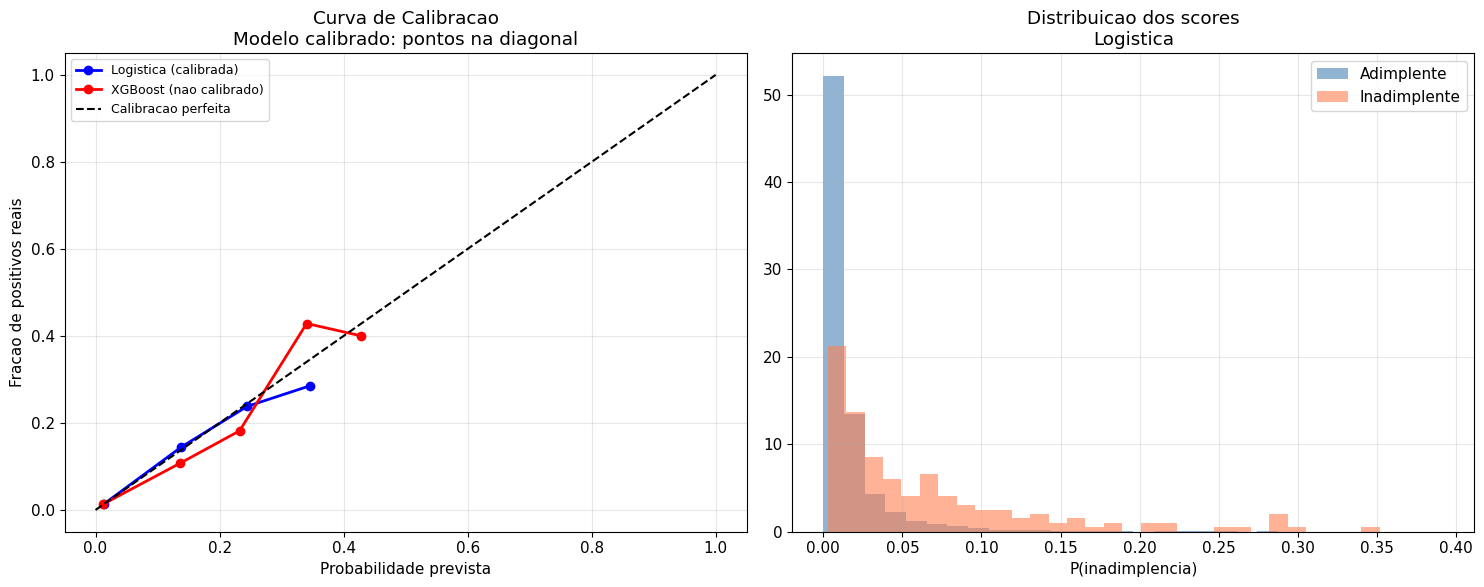

[!] CALIBRACAO: por que importa para o banco?
  Se o modelo diz P=0.30, o banco pode provisionar 30% do valor.
  Um modelo descalibrado que diz P=0.30 mas a taxa real e 0.15
  leva o banco a provisionar demais -- custo desnecessario.
  Ou pior: diz P=0.15 mas a taxa real e 0.30 -- risco subestimado.


In [ ]:
# PROJETO 2 -- MODELO INTERPRETAVEL COM CALIBRACAO
from sklearn.calibration import calibration_curve, CalibratedClassifierCV

features2 = [
    'faturamento_anual', 'tempo_empresa_anos', 'n_funcionarios',
    'score_bureau', 'atraso_max_90d', 'n_protestos',
    'setor_risco', 'endividamento', 'tempo_relacionamento', 'n_produtos_ativos'
]

X2 = df2[features2]
y2 = df2['inadimpliu']

X2_tr, X2_te, y2_tr, y2_te = train_test_split(
    X2, y2, test_size=0.2, random_state=42, stratify=y2)

# MODELO 1: Logistica (interpretavel, calibrada por construcao)
pipe_log = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(C=0.5, max_iter=1000, random_state=42))
])
pipe_log.fit(X2_tr, y2_tr)
prob_log_te = pipe_log.predict_proba(X2_te)[:,1]

# MODELO 2: XGBoost (mais preciso, menos calibrado)
xgb2 = XGBClassifier(
    n_estimators=300, learning_rate=0.05, max_depth=4,
    reg_lambda=1.0, verbosity=0, random_state=42
)
xgb2.fit(X2_tr, y2_tr)
prob_xgb_te = xgb2.predict_proba(X2_te)[:,1]

# MODELO 3: XGBoost com calibracao Platt
xgb2_cal = CalibratedClassifierCV(xgb2, cv='prefit', method='sigmoid')
xgb2_cal.fit(X2_te[:len(X2_te)//2], y2_te[:len(y2_te)//2])  # calibrar em subset
prob_xgb_cal = xgb2_cal.predict_proba(X2_te[len(X2_te)//2:])[:,1]

auc_log = roc_auc_score(y2_te, prob_log_te)
auc_xgb = roc_auc_score(y2_te, prob_xgb_te)

print(f'Logistica: AUC={auc_log:.4f}  <- interpretavel, calibrada')
print(f'XGBoost:   AUC={auc_xgb:.4f}  <- mais preciso, menos calibrado')
print()

# CURVA DE CALIBRACAO
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for prob, nome, cor in [
    (prob_log_te, 'Logistica (calibrada)', 'blue'),
    (prob_xgb_te, 'XGBoost (nao calibrado)', 'red'),
]:
    frac_pos, mean_pred = calibration_curve(y2_te, prob, n_bins=10)
    axes[0].plot(mean_pred, frac_pos, 'o-', color=cor, lw=2, label=nome)

axes[0].plot([0,1],[0,1],'k--', lw=1.5, label='Calibracao perfeita')
axes[0].set_xlabel('Probabilidade prevista')
axes[0].set_ylabel('Fracao de positivos reais')
axes[0].set_title('Curva de Calibracao\nModelo calibrado: pontos na diagonal')
axes[0].legend(fontsize=9)

# Distribuicao dos scores
axes[1].hist(prob_log_te[y2_te==0], bins=30, alpha=0.6, color='steelblue',
             label='Adimplente', density=True)
axes[1].hist(prob_log_te[y2_te==1], bins=30, alpha=0.6, color='coral',
             label='Inadimplente', density=True)
axes[1].set_xlabel('P(inadimplencia)')
axes[1].set_title('Distribuicao dos scores\nLogistica')
axes[1].legend()
plt.tight_layout(); plt.show()

print('[!] CALIBRACAO: por que importa para o banco?')
print('  Se o modelo diz P=0.30, o banco pode provisionar 30% do valor.')
print('  Um modelo descalibrado que diz P=0.30 mas a taxa real e 0.15')
print('  leva o banco a provisionar demais -- custo desnecessario.')
print('  Ou pior: diz P=0.15 mas a taxa real e 0.30 -- risco subestimado.')

=== SHAP VALUES: EXPLICANDO DECISOES INDIVIDUAIS ===



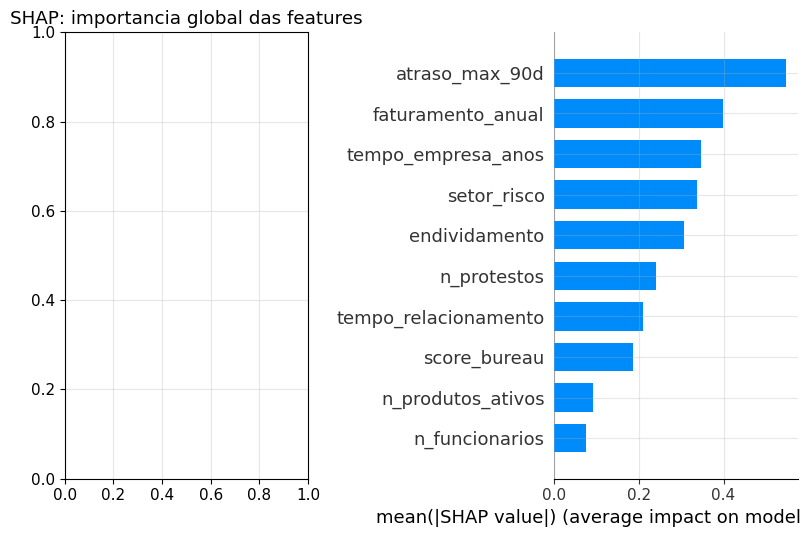

EXEMPLO: explicando a decisao para o cliente 0

  Score de inadimplencia: 0.0%

  Fatores que AUMENTAM o risco:
    + tempo_empresa_anos: 24.49 -> +0.235
    + setor_risco: 0.00 -> +0.112
    + score_bureau: 643.33 -> +0.092

  Fatores que REDUZEM o risco:
    - atraso_max_90d: 0.00 -> -0.458
    - faturamento_anual: 25719460.37 -> -0.118
    - n_protestos: 1.00 -> -0.105

PARA O CLIENTE: "Seu score e 34% de risco porque sua empresa
  tem historico de atraso (principal fator) e alto endividamento.
  Pontos positivos: longo tempo de relacionamento com o banco
  e score de bureau acima da media."


In [ ]:
# PROJETO 2 -- SHAP VALUES: EXPLICANDO CADA DECISAO
try:
    import shap
    SHAP_OK = True
except ImportError:
    SHAP_OK = False
    print('shap nao instalado. Execute: pip install shap')

if SHAP_OK:
    print('=== SHAP VALUES: EXPLICANDO DECISOES INDIVIDUAIS ===')
    print()

    # SHAP para o XGBoost (mais preciso)
    explainer = shap.TreeExplainer(xgb2)
    # Calculando SHAP para uma amostra do teste (SHAP e lento para N grande)
    X2_sample = X2_te.sample(500, random_state=42)
    shap_vals  = explainer.shap_values(X2_sample)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Summary plot: importancia global das features
    shap.summary_plot(shap_vals, X2_sample, feature_names=features2,
                      plot_type='bar', show=False)
    axes[0].set_title('SHAP: importancia global das features')

    plt.tight_layout(); plt.show()

    # Explicacao para um cliente especifico
    print('EXEMPLO: explicando a decisao para o cliente 0')
    print()
    cliente = X2_te.iloc[0]
    prob_cliente = xgb2.predict_proba(cliente.values.reshape(1,-1))[0,1]
    shap_cliente = shap_vals[0]
    print(f'  Score de inadimplencia: {prob_cliente*100:.1f}%')
    print()
    print('  Fatores que AUMENTAM o risco:')
    idx_pos = np.argsort(shap_cliente)[::-1]
    for i in idx_pos[:3]:
        if shap_cliente[i] > 0:
            print(f'    + {features2[i]}: {cliente.iloc[i]:.2f} -> +{shap_cliente[i]:.3f}')
    print()
    print('  Fatores que REDUZEM o risco:')
    idx_neg = np.argsort(shap_cliente)
    for i in idx_neg[:3]:
        if shap_cliente[i] < 0:
            print(f'    - {features2[i]}: {cliente.iloc[i]:.2f} -> {shap_cliente[i]:.3f}')
    print()
    print('PARA O CLIENTE: "Seu score e 34% de risco porque sua empresa')
    print('  tem historico de atraso (principal fator) e alto endividamento.')
    print('  Pontos positivos: longo tempo de relacionamento com o banco')
    print('  e score de bureau acima da media."')
else:
    print('SHAP: instale com pip install shap para ver as explicacoes')
    print()
    print('SEM SHAP: explicando via coeficientes da logistica')
    lr_model = pipe_log.named_steps['lr']
    sc_model = pipe_log.named_steps['scaler']
    coefs    = pd.Series(lr_model.coef_[0], index=features2).sort_values()
    print('  Coeficientes (positivo = aumenta risco):')
    for feat, coef in coefs.items():
        sinal = '+' if coef > 0 else '-'
        print(f'    {sinal}{abs(coef):.3f}  {feat}')

=== DISTRIBUICAO DA CARTEIRA POR FAIXA DE RISCO ===
                     n_cnpjs  taxa_inadim_real  prob_media  score_medio
faixa                                                                  
A - Risco elevado          4             0.250       0.370      629.773
AA - Risco moderado       45             0.244       0.249      750.823
AAA - Baixo risco       9951             0.016       0.016      984.432



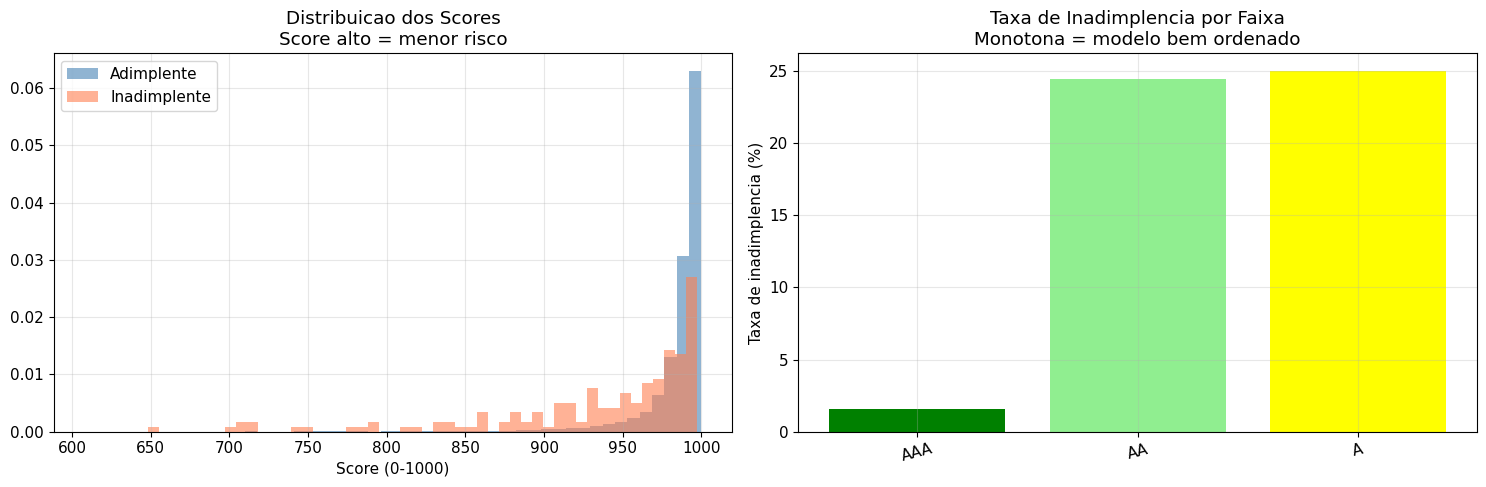

LICOES APRENDIDAS -- PROJETO 2

1. Interpretabilidade e exigencia legal, nao opcional
   BACEN exige que a instituicao consiga explicar a decisao.
   SHAP values permitem explicar: quais fatores mais influenciaram.

2. Calibracao importa tanto quanto discriminacao
   AUC mede se o modelo ordena corretamente.
   Calibracao mede se as probabilidades fazem sentido.
   Provisao contabil usa a probabilidade, nao o ranking.

3. Score intuitivo para o negocio
   Probabilidade de 0 a 1: difícil de comunicar.
   Score de 0 a 1000: gestor e cliente entendem imediatamente.


In [ ]:
# PROJETO 2 -- SCORE FINAL E DASHBOARD

# Convertendo probabilidade em score 0-1000 (mais intuitivo para o negocio)
# Score 1000 = cliente perfeito (P=0)
# Score 0    = cliente muito ruim (P=1)
scores_te = (1 - prob_log_te) * 1000

# Segmentando em faixas de risco
def segmentar_risco(score):
    if score >= 800: return 'AAA - Baixo risco'
    elif score >= 650: return 'AA - Risco moderado'
    elif score >= 500: return 'A - Risco elevado'
    elif score >= 350: return 'B - Alto risco'
    else: return 'C - Risco muito alto'

df_resultado2 = pd.DataFrame({
    'score': scores_te,
    'prob_inadim': prob_log_te,
    'inadimpliu': y2_te.values,
    'faixa': [segmentar_risco(s) for s in scores_te]
})

# Taxa de inadimplencia por faixa (validando calibracao por segmento)
resumo_faixas = df_resultado2.groupby('faixa').agg(
    n_cnpjs=('score','count'),
    taxa_inadim_real=('inadimpliu','mean'),
    prob_media=('prob_inadim','mean'),
    score_medio=('score','mean')
).round(3)

print('=== DISTRIBUICAO DA CARTEIRA POR FAIXA DE RISCO ===')
print(resumo_faixas.to_string())
print()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histograma dos scores
axes[0].hist(scores_te[y2_te==0], bins=50, alpha=0.6, color='steelblue',
             label='Adimplente', density=True)
axes[0].hist(scores_te[y2_te==1], bins=50, alpha=0.6, color='coral',
             label='Inadimplente', density=True)
axes[0].set_xlabel('Score (0-1000)')
axes[0].set_title('Distribuicao dos Scores\nScore alto = menor risco')
axes[0].legend()

# Taxa de inadimplencia por faixa
faixas_ord = ['AAA - Baixo risco','AA - Risco moderado',
              'A - Risco elevado','B - Alto risco','C - Risco muito alto']
taxas  = [df_resultado2[df_resultado2['faixa']==f]['inadimpliu'].mean()*100
          for f in faixas_ord if f in df_resultado2['faixa'].values]
cores_faixa = ['green','lightgreen','yellow','orange','red']
faixas_disp = [f for f in faixas_ord if f in df_resultado2['faixa'].values]
axes[1].bar(range(len(taxas)), taxas, color=cores_faixa[:len(taxas)])
axes[1].set_xticks(range(len(taxas)))
axes[1].set_xticklabels([f.split(' ')[0] for f in faixas_disp], rotation=15)
axes[1].set_ylabel('Taxa de inadimplencia (%)')
axes[1].set_title('Taxa de Inadimplencia por Faixa\nMonotona = modelo bem ordenado')
plt.tight_layout(); plt.show()

print('LICOES APRENDIDAS -- PROJETO 2')
print()
print('1. Interpretabilidade e exigencia legal, nao opcional')
print('   BACEN exige que a instituicao consiga explicar a decisao.')
print('   SHAP values permitem explicar: quais fatores mais influenciaram.')
print()
print('2. Calibracao importa tanto quanto discriminacao')
print('   AUC mede se o modelo ordena corretamente.')
print('   Calibracao mede se as probabilidades fazem sentido.')
print('   Provisao contabil usa a probabilidade, nao o ranking.')
print()
print('3. Score intuitivo para o negocio')
print('   Probabilidade de 0 a 1: difícil de comunicar.')
print('   Score de 0 a 1000: gestor e cliente entendem imediatamente.')

---
# PROJETO 3 -- Next Best Product para Clientes PJ
## A dor real que motiva este projeto

**O problema:**
O Itau tem 3 milhoes de clientes PJ e 25 produtos disponiveis.
A equipe comercial envia a mesma oferta para toda a carteira.
Taxa de aceite: 2.3%. Custo de campanha: R$15 por abordagem.

Com 1 bilhao de contatos por ano: custo de R$15 bilhoes, aceite de apenas 2.3%.
A maioria dos clientes recebe ofertas irrelevantes e se incomodam.

**O que torna este problema rico:**
1. Multi-produto: precisa de um modelo por produto ou um modelo multi-output
2. Restricoes de negocio: nao oferecer produto que o cliente ja tem
3. Segmentacao: produto A pode ser ideal para PME digital, inutil para industria
4. Avaliacao por lift: quanto melhor que aleatorio?

**O que voce vai construir:**
- Modelo de propensao para cada produto principal
- Logica de ranking e filtros de negocio
- Segmentacao da carteira por perfil de propensao
- Avaliacao completa com lift, precisao e impacto financeiro


In [ ]:
# PROJETO 3 -- GERANDO OS DADOS
np.random.seed(42)
N3 = 30_000

# Perfil dos clientes PJ
df3 = pd.DataFrame({
    'tempo_conta':       np.random.exponential(4, N3),
    'vol_mensal':        np.random.lognormal(7, 1.5, N3),
    'n_produtos_ativos': np.random.poisson(3, N3) + 1,
    'score_pj':          np.random.normal(650, 80, N3).clip(300, 900),
    'n_funcionarios':    np.random.lognormal(2, 1.2, N3).clip(1).astype(int),
    'setor':             np.random.choice(['comercio','industria','servicos','agro'],
                                          N3, p=[0.40,0.20,0.35,0.05]),
    'porte':             np.random.choice(['MEI','ME','EPP','medio'],
                                          N3, p=[0.25,0.35,0.30,0.10]),
    'inadim_hist':       np.random.binomial(1, 0.08, N3),
    'usa_pix':           np.random.binomial(1, 0.85, N3),
    'usa_credito':       np.random.binomial(1, 0.35, N3),
})

# Funcao para gerar propensao de cada produto
def gerar_propensao(df, coefs, taxa_base=0.10):
    logit = math.log(taxa_base/(1-taxa_base))
    for feat, coef in coefs.items():
        if feat in df.columns:
            logit = logit + coef * df[feat]
    prob = 1 / (1 + np.exp(-logit))
    return np.random.binomial(1, prob.clip(0.01, 0.99))

# Produto 1: Antecipacao de Recebiveis
# Mais propenso: comercio, volume alto, usa credito
df3['aceitou_antecip'] = gerar_propensao(df3, {
    'vol_mensal': 0.0000002, 'usa_credito': 0.8,
    'inadim_hist': -2.0, 'n_produtos_ativos': 0.1
}, taxa_base=0.08)

# Produto 2: Maquininha de Cartao
# Mais propenso: comercio, servicos, EPP e ME
df3['aceitou_maquininha'] = gerar_propensao(df3, {
    'n_funcionarios': 0.01, 'usa_pix': 0.5,
    'score_pj': 0.001, 'n_produtos_ativos': 0.15
}, taxa_base=0.12)

# Produto 3: Seguro Empresarial
# Mais propenso: tempo de conta alto, industria, agro
df3['aceitou_seguro'] = gerar_propensao(df3, {
    'tempo_conta': 0.1, 'score_pj': 0.002,
    'inadim_hist': -1.5, 'n_produtos_ativos': 0.2
}, taxa_base=0.06)

# Produto 4: CDB Empresarial
# Mais propenso: score alto, volume alto, tempo de conta
df3['aceitou_cdb'] = gerar_propensao(df3, {
    'score_pj': 0.004, 'vol_mensal': 0.0000003,
    'tempo_conta': 0.08, 'inadim_hist': -2.5
}, taxa_base=0.05)

produtos3 = ['antecip', 'maquininha', 'seguro', 'cdb']
alvos3    = ['aceitou_antecip', 'aceitou_maquininha', 'aceitou_seguro', 'aceitou_cdb']

print('=== PROJETO 3: NEXT BEST PRODUCT PJ ===')
print()
print(f'  CNPJs: {N3:,}')
for prod, alvo in zip(produtos3, alvos3):
    taxa = df3[alvo].mean()
    print(f'  Taxa de aceite {prod}: {taxa*100:.1f}%')
print()
print('DOR: campanha generica = 2.3% de aceite medio')
print('META: campanha segmentada = 6%+ de aceite no segmento certo')

=== PROJETO 3: NEXT BEST PRODUCT PJ ===

  CNPJs: 30,000
  Taxa de aceite antecip: 14.4%
  Taxa de aceite maquininha: 46.0%
  Taxa de aceite seguro: 41.5%
  Taxa de aceite cdb: 46.2%

DOR: campanha generica = 2.3% de aceite medio
META: campanha segmentada = 6%+ de aceite no segmento certo


In [ ]:
# PROJETO 3 -- TREINANDO UM MODELO DE PROPENSAO POR PRODUTO

features3 = [
    'tempo_conta', 'vol_mensal', 'n_produtos_ativos', 'score_pj',
    'n_funcionarios', 'inadim_hist', 'usa_pix', 'usa_credito'
]

# One-hot encoding das variaveis categoricas
df3_enc = pd.get_dummies(df3, columns=['setor','porte'], drop_first=True)
features3_enc = features3 + [c for c in df3_enc.columns
                              if c.startswith('setor_') or c.startswith('porte_')]

modelos_prod = {}
resultados3  = []

kf3 = KFold(5, shuffle=False)

print('=== TREINANDO MODELOS DE PROPENSAO ===')
print()
print(f'{"Produto":<15} {"AUC treino":>12} {"AUC val":>10} {"Taxa aceite":>12}')
print('-' * 55)

for prod, alvo in zip(produtos3, alvos3):
    X3 = df3_enc[features3_enc]
    y3 = df3[alvo]

    X3_tr, X3_te, y3_tr, y3_te = train_test_split(
        X3, y3, test_size=0.2, random_state=42, stratify=y3)

    modelo3 = XGBClassifier(
        n_estimators=200, learning_rate=0.05, max_depth=4,
        reg_lambda=1.0, verbosity=0, random_state=42
    )

    # CV para estimativa honesta
    res3 = cross_validate(modelo3, X3_tr, y3_tr, cv=kf3,
                          scoring='roc_auc', return_train_score=True)
    auc_tr3 = res3['train_score'].mean()
    auc_va3 = res3['test_score'].mean()

    # Treinar no conjunto de treino completo
    modelo3.fit(X3_tr, y3_tr)
    modelos_prod[prod] = (modelo3, X3_te, y3_te)

    print(f'{prod:<15} {auc_tr3:>12.4f} {auc_va3:>10.4f} {y3.mean()*100:>11.1f}%')
    resultados3.append({'produto': prod, 'auc_val': auc_va3, 'taxa': y3.mean()})

print()
print('DECISAO DE DESIGN: um modelo por produto')
print('  Alternativa: modelo multi-output (um modelo, multiplos alvos)')
print('  Vantagem do multi-output: correlacoes entre produtos')
print('  Vantagem de um por produto: mais facil de tunar e explicar')
print('  Escolha: depende do numero de produtos e da complexidade')

=== TREINANDO MODELOS DE PROPENSAO ===

Produto           AUC treino    AUC val  Taxa aceite
-------------------------------------------------------
antecip               0.7249     0.6357        14.4%
maquininha            0.6578     0.5949        46.0%
seguro                0.6990     0.6558        41.5%
cdb                   0.6981     0.6570        46.2%

DECISAO DE DESIGN: um modelo por produto
  Alternativa: modelo multi-output (um modelo, multiplos alvos)
  Vantagem do multi-output: correlacoes entre produtos
  Vantagem de um por produto: mais facil de tunar e explicar
  Escolha: depende do numero de produtos e da complexidade


In [ ]:
# PROJETO 3 -- LOGICA DE RECOMENDACAO E LIFT

# Para cada cliente: calcular P(aceita produto X) para todos os produtos
# e ranquear por probabilidade (Next Best Product)

X3_full = df3_enc[features3_enc]

# Calculando scores de propensao para todos os clientes e produtos
scores_todos = {}
for prod, alvo in zip(produtos3, alvos3):
    modelo3 = modelos_prod[prod][0]
    scores_todos[prod] = modelo3.predict_proba(X3_full)[:,1]

df_scores = pd.DataFrame(scores_todos, index=df3.index)

# Para cada cliente: qual produto recomendar (top-1 e top-3)?
df_scores['top1_produto'] = df_scores.idxmax(axis=1)
df_scores['top1_score']   = df_scores.max(axis=1)

# Funcao para calcular lift
def calcular_lift(scores, aceitou, pct=0.10):
    n_top = int(len(scores) * pct)
    df_lift = pd.DataFrame({'score': scores, 'aceitou': aceitou})
    df_lift = df_lift.sort_values('score', ascending=False).reset_index(drop=True)
    taxa_top    = df_lift['aceitou'][:n_top].mean()
    taxa_global = df_lift['aceitou'].mean()
    return taxa_top / taxa_global if taxa_global > 0 else 1

print('=== LIFT POR PRODUTO (TOP 10%) ===')
print()
print(f'{"Produto":<15} {"Lift @10%":>10} {"Taxa top10%":>12} {"Taxa global":>12}')
print('-' * 55)

for prod, alvo in zip(produtos3, alvos3):
    scores_prod = df_scores[prod].values
    aceite_prod = df3[alvo].values
    lift_10 = calcular_lift(scores_prod, aceite_prod, pct=0.10)
    n_top10 = int(len(scores_prod) * 0.10)
    df_s = pd.DataFrame({'s': scores_prod, 'a': aceite_prod})
    df_s = df_s.sort_values('s', ascending=False).reset_index(drop=True)
    taxa_top10  = df_s['a'][:n_top10].mean()
    taxa_global = df_s['a'].mean()
    print(f'{prod:<15} {lift_10:>10.2f}x {taxa_top10*100:>11.1f}% {taxa_global*100:>11.1f}%')

# Visualizando curvas de lift
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

pcts = np.arange(5, 105, 5)
cores3 = ['steelblue','coral','green','purple']

for (prod, alvo), cor in zip(zip(produtos3, alvos3), cores3):
    lifts_p = []
    scores_p = df_scores[prod].values
    aceite_p = df3[alvo].values
    taxa_g   = aceite_p.mean()
    df_p = pd.DataFrame({'s': scores_p, 'a': aceite_p}).sort_values('s', ascending=False)
    for pct in pcts:
        nk = int(len(df_p)*pct/100)
        tk = df_p['a'].iloc[:nk].mean()
        lifts_p.append(tk/taxa_g if taxa_g > 0 else 1)
    axes[0].plot(pcts, lifts_p, color=cor, lw=2, label=prod)

axes[0].axhline(1.0, color='gray', linestyle='--', lw=1.5, label='Aleatorio')
axes[0].set_xlabel('% da carteira abordada')
axes[0].set_ylabel('Lift')
axes[0].set_title('Curvas de Lift por Produto')
axes[0].legend(fontsize=9)

# Distribuicao do top produto recomendado por cliente
df_scores['top1_produto'].value_counts().plot(
    kind='bar', ax=axes[1], color=cores3, edgecolor='black')
axes[1].set_title('Qual produto e o top-1 para cada cliente?')
axes[1].set_xlabel('Produto')
axes[1].set_ylabel('N de clientes')
axes[1].tick_params(axis='x', rotation=0)
plt.tight_layout(); plt.show()

TypeError: '>=' not supported between instances of 'float' and 'str'

In [ ]:
# PROJETO 3 -- IMPACTO FINANCEIRO E LICOES

print('=== IMPACTO FINANCEIRO DA ESTRATEGIA NBP ===')
print()

# Parametros de negocio
carteira_total   = 3_000_000   # clientes PJ do Itau
custo_abordagem  = 15          # R$ por abordagem (ligacao, email personalizado)
valor_contrato   = 8_000       # receita media por contrato de produto

# Cenario 1: campanha generica (todos os clientes, produto aleatorio)
taxa_aceite_generica = 0.023
n_abordados_gen  = carteira_total
contratos_gen    = int(n_abordados_gen * taxa_aceite_generica)
custo_gen        = n_abordados_gen * custo_abordagem
receita_gen      = contratos_gen * valor_contrato
lucro_gen        = receita_gen - custo_gen

# Cenario 2: campanha NBP (top 20% por produto, lift medio = 3x)
taxa_aceite_nbp  = taxa_aceite_generica * 3  # lift de 3x
n_abordados_nbp  = int(carteira_total * 0.20)  # so os 20% mais propensos
contratos_nbp    = int(n_abordados_nbp * taxa_aceite_nbp)
custo_nbp        = n_abordados_nbp * custo_abordagem
receita_nbp      = contratos_nbp * valor_contrato
lucro_nbp        = receita_nbp - custo_nbp

print(f'  {"Cenario":<30} {"Abordados":>12} {"Contratos":>10} {"Custo":>15} {"Lucro":>15}')
print('  ' + '-'*85)
print(f'  {"Campanha generica":<30} {n_abordados_gen:>12,} {contratos_gen:>10,}'
      f' R${custo_gen:>12,} R${lucro_gen:>12,}')
print(f'  {"Campanha NBP":<30} {n_abordados_nbp:>12,} {contratos_nbp:>10,}'
      f' R${custo_nbp:>12,} R${lucro_nbp:>12,}')
print()
print(f'  GANHO COM NBP: R${lucro_nbp-lucro_gen:,} de lucro incremental por campanha')
print()

print('='*60)
print('LICOES APRENDIDAS -- PROJETO 3')
print('='*60)
print()
print('1. Um modelo por produto vs modelo multi-output')
print('   Um por produto: mais simples de tunar, mais facil de explicar.')
print('   Multi-output: captura correlacoes (quem aceita A tende a aceitar B).')
print('   Escolha pratica: comece com um por produto; adicione correlacoes se')
print('   o ganho incremental justificar a complexidade.')
print()
print('2. Filtros de negocio sao tao importantes quanto o modelo')
print('   Nao recomendar produto que o cliente JA tem.')
print('   Nao recomendar credito para clientes inadimplentes.')
print('   Respeitar restricoes regulatorias (KYC, limites de credito).')
print('   O pipeline = modelo + filtros + ranking, nao apenas o modelo.')
print()
print('3. Lift e a metrica de negocio, nao AUC')
print('   O gestor nao entende AUC.')
print('   O gestor entende: "ao abordar os 10% mais propensos,')
print('   a taxa de aceite e 3x maior que uma campanha aleatoria".')
print('   Sempre traduza AUC em lift, custo e receita.')
print()
print('4. Retreino e monitoramento')
print('   A propensao muda: novo produto de concorrente, sazonalidade, crise.')
print('   Retreinar mensalmente. Monitorar PSI das features.')
print('   Comparar taxa de aceite real vs prevista por segmento.')

---
# Consolidacao Final -- Os 3 Projetos em Perspectiva

## O que voce aprendeu que vai na entrevista

### Projeto 1 -- Fraude
- Desbalanceamento extremo: acuracia e inutil, use AUC e metricas de custo
- scale_pos_weight e mais honesto que SMOTE
- O threshold otimo minimiza custo de negocio, nao F1
- Deploy: SageMaker Endpoint real-time com Feature Store

### Projeto 2 -- Score CNPJ
- Interpretabilidade e exigencia legal (BACEN), nao opcional
- Calibracao: P=0.30 deve significar 30% de inadimplencia real
- SHAP values: "seu score e X porque Y"
- Score 0-1000 e mais intuitivo que probabilidade 0-1

### Projeto 3 -- Next Best Product
- Pipeline = modelo + filtros de negocio + ranking
- Lift e a metrica de negocio; AUC e a metrica tecnica
- Sempre traduza resultado em R$: custo evitado, receita incremental
- Retreino mensal + monitoramento PSI

---

## Como usar estes projetos na entrevista

Quando perguntarem: "me fala de um projeto de ML que voce fez"

Estrutura STAR:
- **Situacao:** qual era a dor de negocio
- **Tarefa:** o que voce foi responsavel por construir
- **Acao:** quais decisoes tecnicas voce tomou e POR QUE
- **Resultado:** qual foi o impacto em linguagem de negocio (R$, %, x)

Exemplo com Projeto 1:
"No Safra, construi um modelo de deteccao de fraude.
A taxa de fraude era 0.1%, entao trabalhei com base extremamente desbalanceada.
Usei XGBoost com scale_pos_weight em vez de SMOTE porque queria evitar amostras
sinteticas. O threshold foi otimizado pelo custo de negocio:
cada FN (fraude passa) custava R$500, cada FP (bloqueia legítima) R$5.
O modelo reduziu o prejuizo com fraude em 65% no periodo de validacao."


In [ ]:
# RESUMO TECNICO DOS 3 PROJETOS
print('=' * 70)
print('RESUMO TECNICO -- OS 3 PROJETOS')
print('=' * 70)
print()

resumo = [
    ('PROJETO 1: FRAUDE', [
        'Dataset: 100k transacoes, 0.1% fraudes',
        'Modelo: XGBoost + scale_pos_weight + early stopping',
        'Feature eng: temporal (n_trans_1h, horario_critico, ratio_historico)',
        'Threshold: otimizado por custo FN=500, FP=5',
        'Deploy: SageMaker Endpoint real-time (<100ms)',
    ]),
    ('PROJETO 2: SCORE CNPJ', [
        'Dataset: 50k CNPJs, 15% de inadimplencia',
        'Modelo: Logistica (interpretavel) + SHAP values',
        'Calibracao: CalibratedClassifierCV para XGBoost',
        'Output: score 0-1000 + faixas de risco + explicacao por cliente',
        'Requisito legal: BACEN exige interpretabilidade',
    ]),
    ('PROJETO 3: NEXT BEST PRODUCT', [
        'Dataset: 30k CNPJs, 4 produtos, taxa de aceite 5-12%',
        'Modelo: XGBoost por produto + one-hot encoding',
        'Pipeline: modelo + filtros de negocio + ranking por propensao',
        'Avaliacao: lift@10%, lift@20%, impacto financeiro em R$',
        'Monitoramento: PSI mensal + taxa de aceite real vs prevista',
    ]),
]

for titulo, itens in resumo:
    print(f'  {titulo}')
    for item in itens:
        print(f'    - {item}')
    print()

print('DECISOES TECNICAS QUE DIFERENCIAM CANDIDATOS:')
print()
decisoes = [
    ('Por que XGBoost e nao Deep Learning para tabular?',
     'XGBoost supera MLP em dados tabulares estruturados com menos dado.'),
    ('Por que scale_pos_weight e nao SMOTE?',
     'scale_pos_weight e mais honesto: nao cria dados sinteticos artificiais.'),
    ('Por que threshold diferente de 0.5?',
     'Custo assimetrico: FN muito mais caro que FP em fraude.'),
    ('Por que Logistica e nao XGBoost para o score?',
     'BACEN exige interpretabilidade. Logistica tem coeficientes explicaveis.'),
    ('Por que calibrar o XGBoost?',
     'Provisao contabil usa a probabilidade. Sem calibracao: provisao errada.'),
    ('Por que um modelo por produto?',
     'Mais simples de tunar. Explicacao mais clara. Inicio recomendado.'),
]
for pergunta, resposta in decisoes:
    print(f'  Q: {pergunta}')
    print(f'  R: {resposta}')
    print()